# Commercial analysis

The evaluation notebook showed that the GBM predicts claim cost better than the GLM. This notebook asks what that means in money:

> If we priced with the GBM instead of the GLM, which customers would we be undercharging or overcharging today, and roughly how much would that cost us?

It then looks inside the GBM with SHAP values, compares what it has learned with the GLM's relativities, and tests whether the main thing the GBM found can be fed back into the GLM.

Throughout, "GLM" and "GBM" mean the frequency x severity pure premium models, the best GLM and GBM from the evaluation notebook. Money is in euros of capped claim cost on the test portfolio (135,603 policies, about 71,600 policy-years); the large-loss loading is left out because it scales every premium by the same factor.

In [1]:
import gc
import pickle

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import shap
from sklearn.tree import DecisionTreeRegressor

from pricing.data import LARGE_LOSS_CAP, PROJECT_ROOT, RANDOM_SEED, build_policy_table, load_raw, split_train_test
from pricing.evaluation import gini, leaf_rules, mispricing_table, poisson_deviance, tweedie_deviance
from pricing.features import (
    BANDS, add_glm_bands, band_labels, gbm_matrix, glm_design_matrix, off_discount_path,
)
from pricing.gbm import to_numeric
from pricing.glm import fit_poisson_glm, predict, relativities
from pricing.plots import (
    plot_importance, plot_mispricing, plot_relativity_comparison, plot_shap_dependence, save, set_style,
)

set_style()
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(3)
pl.Config.set_fmt_str_lengths(60)
PROCESSED = PROJECT_ROOT / "data" / "processed"

## 1. Load the frozen models

The saved models are applied to both the training and the test data. Training-set predictions are used to find segments and explain the GBM; the test set is used only to check those findings against actual claims.

In [2]:
freq_raw, sev_raw = load_raw()
train, test = split_train_test(build_policy_table(freq_raw, sev_raw, large_loss_cap=LARGE_LOSS_CAP))

with open(PROCESSED / "frequency_glm.pkl", "rb") as fh:
    freq_glm = pickle.load(fh)
with open(PROCESSED / "severity_glm.pkl", "rb") as fh:
    sev_glm = pickle.load(fh)
with open(PROCESSED / "frequency_gbm_meta.pkl", "rb") as fh:
    freq_gbm_meta = pickle.load(fh)
freq_gbm = lgb.Booster(model_file=str(PROCESSED / "frequency_gbm.txt"))
sev_gbm = lgb.Booster(model_file=str(PROCESSED / "severity_gbm.txt"))


def model_predictions(df):
    banded, G = add_glm_bands(df), gbm_matrix(df)
    freq_glm_rate = predict(freq_glm["results"], glm_design_matrix(banded, freq_glm["levels"], freq_glm["base"]))
    sev_glm_cost = predict(sev_glm["results"], glm_design_matrix(banded, sev_glm["levels"], sev_glm["base"]))
    freq_gbm_rate = np.exp(freq_gbm.predict(G, raw_score=True) + np.log(freq_gbm_meta["base_rate"]))
    return {"freq_glm": freq_glm_rate, "freq_gbm": freq_gbm_rate,
            "glm": freq_glm_rate * sev_glm_cost, "gbm": freq_gbm_rate * sev_gbm.predict(G)}


pred_train, pred_test = model_predictions(train), model_predictions(test)

saved = pl.read_parquet(PROCESSED / "pure_premium_test_predictions.parquet")
assert np.allclose(pred_test["glm"], saved["pp_glm_fs"].to_numpy()) and np.allclose(pred_test["gbm"], saved["pp_gbm_fs"].to_numpy())

## 2. Who would pay more and who would pay less

To separate **who pays what** from **how much is charged in total**, both models are scaled so that each charges exactly the test set's total claim cost. Any difference between them is then pure redistribution: every euro one customer pays less, another pays more.

Policies are grouped by the ratio of the GBM's price to the GLM's price. Where the ratio is below 1, the GLM charges more than the GBM thinks the policy costs; above 1, less.

In [3]:
cost, expo = test["ClaimAmount"].to_numpy(), test["Exposure"].to_numpy()
total = cost.sum()
glm_prem = pred_test["glm"] * total / np.sum(pred_test["glm"] * expo)
gbm_prem = pred_test["gbm"] * total / np.sum(pred_test["gbm"] * expo)

portfolio = test.select("IDpol", "DrivAge", "BonusMalus", "VehAge", "Density", "Region").with_columns(
    exposure=pl.Series(expo), observed=pl.Series(cost), glm=pl.Series(glm_prem), gbm=pl.Series(gbm_prem),
).with_columns(
    (pl.col("gbm") / pl.col("glm")).alias("ratio"),
).with_columns(
    pl.col("ratio").cut([0.8, 0.9, 1.1, 1.25], labels=["GBM below 0.8x GLM", "0.8 to 0.9x", "0.9 to 1.1x", "1.1 to 1.25x", "GBM above 1.25x GLM"]).alias("ratio_band"),
    test.select(off_discount_path()).to_series(),
)

by_ratio = mispricing_table(portfolio, "ratio_band")
by_ratio

ratio_band,policies,exposure,observed,glm_premium,gbm_premium,shift,observed_over_glm,observed_over_gbm
enum,u32,f64,f64,f64,f64,f64,f64,f64
"""GBM below 0.8x GLM""",29007,15801.568,1910317.910,2843645.707,1875175.754,-968469.953,0.672,1.019
"""0.8 to 0.9x""",18418,10771.821,1184612.700,1411445.751,1200529.561,-210916.190,0.839,0.987
"""0.9 to 1.1x""",37130,20702.420,2385960.200,2515882.563,2500247.658,-15634.905,0.948,0.954
"""1.1 to 1.25x""",20475,10310.741,1366018.670,1229127.921,1437601.058,208473.137,1.111,0.950
"""GBM above 1.25x GLM""",30573,14009.643,2856673.690,1703481.228,2690029.139,986547.911,1.677,1.062


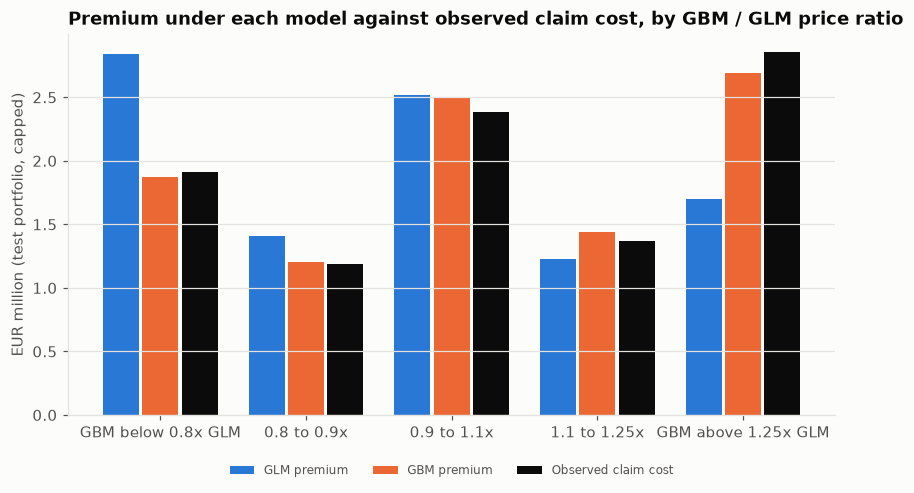

In [4]:
fig = plot_mispricing(by_ratio, "ratio_band", "Premium under each model against observed claim cost, by GBM / GLM price ratio")
save(fig, "com_mispricing_by_ratio")
plt.show()

In [5]:
redistributed = float(np.sum(np.abs(gbm_prem - glm_prem) * expo) / 2)
under = by_ratio.filter(pl.col("ratio_band").cast(pl.String).is_in(["1.1 to 1.25x", "GBM above 1.25x GLM"]))
over = by_ratio.filter(pl.col("ratio_band").cast(pl.String).is_in(["GBM below 0.8x GLM", "0.8 to 0.9x"]))
pl.DataFrame({
    "measure": [
        "total premium (= total capped claim cost)",
        "premium that would move between customers",
        "  as a share of total premium",
        "GLM-undercharged customers (GBM > 1.1x GLM): policies",
        "  premium under the GLM",
        "  observed claim cost",
        "  shortfall under the GLM (observed - premium)",
        "GLM-overcharged customers (GBM < 0.9x GLM): policies",
        "  premium under the GLM",
        "  observed claim cost",
        "  excess under the GLM (premium - observed)",
    ],
    "value": [
        total, redistributed, redistributed / total,
        float(under["policies"].sum()), under["glm_premium"].sum(), under["observed"].sum(),
        under["observed"].sum() - under["glm_premium"].sum(),
        float(over["policies"].sum()), over["glm_premium"].sum(), over["observed"].sum(),
        over["glm_premium"].sum() - over["observed"].sum(),
    ],
})

measure,value
str,f64
"""total premium (= total capped claim cost)""",9703583.170
"""premium that would move between customers""",1249187.191
""" as a share of total premium""",0.129
"""GLM-undercharged customers (GBM > 1.1x GLM): policies""",51048.000
""" premium under the GLM""",2932609.149
""" observed claim cost""",4222692.360
""" shortfall under the GLM (observed - premium)""",1290083.211
"""GLM-overcharged customers (GBM < 0.9x GLM): policies""",47425.000
""" premium under the GLM""",4255091.458


The answer to the headline question, on this test portfolio:

- **About 13% of premium would move between customers** (about EUR 1.25m of EUR 9.7m) if the GBM's prices replaced the GLM's with the same total.
- **The GBM's re-rating is confirmed by what actually happened.** In the two groups where the GBM prices highest relative to the GLM, observed claims came to about EUR 4.2m against EUR 2.9m of GLM premium: the GLM undercharged these customers by roughly EUR 1.3m. In the two groups where the GBM prices lowest, the GLM charged about EUR 4.3m for EUR 3.1m of claims: an overcharge of roughly EUR 1.2m. In each of the four outer groups, observed cost is much closer to the GBM's premium than to the GLM's; in the middle group, where the models roughly agree, both are about equally close.

The two halves cost the insurer money in different ways:

- **Undercharged customers** stay, because the price is good, and generate losses directly: about EUR 1.3m on this test portfolio.
- **Overcharged customers** are likely to leave for a competitor that prices them more accurately. The insurer loses the margin on them, and its remaining book tilts towards the undercharged risks. This is **adverse selection**. Its cost depends on how price-sensitive customers are, which cannot be measured without price and conversion data, so it is not estimated here.

The test set is a fifth of the data. For a book the size of the full dataset (about 360,000 policy-years of exposure), the undercharge would be roughly five times larger, around EUR 6 to 7m of capped claim cost, but that scaling assumes the full book looks like this sample.

## 3. Which customers: segments where the GLM misprices most

The ratio bands say how much is mispriced but not who those customers are. To describe them in rating-factor terms, a shallow decision tree is fitted on the **training** set to explain the log of the GBM / GLM price ratio from driver age, BonusMalus, vehicle age and density. Each leaf of the tree is a segment described by a few simple rules. The segments are then applied to the test set, where observed claims show whether the disagreement was real.

In [6]:
seg_features = ["DrivAge", "BonusMalus", "VehAge", "Density"]
log_ratio_train = np.log(pred_train["gbm"] / pred_train["glm"])
tree = DecisionTreeRegressor(max_depth=4, min_weight_fraction_leaf=0.01, random_state=RANDOM_SEED)
tree.fit(train.select(seg_features).to_numpy(), log_ratio_train, sample_weight=train["Exposure"].to_numpy())

fitted = tree.predict(train.select(seg_features).to_numpy())
w = train["Exposure"].to_numpy()
r2 = 1 - np.average((log_ratio_train - fitted) ** 2, weights=w) / np.average((log_ratio_train - np.average(log_ratio_train, weights=w)) ** 2, weights=w)
print(f"Share of the variation in the GBM / GLM ratio explained by the segments: {r2:.0%}")

rules = leaf_rules(tree, seg_features)
portfolio = portfolio.with_columns(pl.Series("segment", [rules[int(i)] for i in tree.apply(test.select(seg_features).to_numpy())]))
segments = mispricing_table(portfolio, "segment").sort("shift")
segments.select("segment", "policies", "exposure", "glm_premium", "gbm_premium", "observed", "shift", "observed_over_glm", "observed_over_gbm")

Share of the variation in the GBM / GLM ratio explained by the segments: 20%


segment,policies,exposure,glm_premium,gbm_premium,observed,shift,observed_over_glm,observed_over_gbm
str,u32,f64,f64,f64,f64,f64,f64,f64
"""VehAge < 8, BonusMalus >= 100""",2516,911.178,494798.880,383902.152,370574.750,-110896.728,0.749,0.965
"""VehAge >= 8, DrivAge < 70, 51 <= BonusMalus < 55""",3533,1987.202,265518.369,189737.529,137926.890,-75780.841,0.519,0.727
"""VehAge >= 8, DrivAge < 70, BonusMalus >= 55""",23309,10760.621,2455371.470,2405145.950,2187264.520,-50225.520,0.891,0.909
"""VehAge >= 8, 53 <= DrivAge < 70, BonusMalus < 51""",9402,6533.737,578088.603,530950.293,449393.050,-47138.310,0.777,0.846
"""VehAge < 8, BonusMalus < 51, 70 <= DrivAge < 78""",3368,2033.954,235443.110,193616.731,219837.190,-41826.379,0.934,1.135
"""VehAge < 8, 51 <= BonusMalus < 52""",1756,839.576,118000.401,82959.249,134666.620,-35041.152,1.141,1.623
"""VehAge >= 8, 70 <= DrivAge < 79, Density >= 97""",1554,1178.824,163756.358,133442.799,134237.360,-30313.560,0.820,1.006
"""VehAge >= 8, 70 <= DrivAge < 79, Density < 97""",913,755.631,76179.550,59892.393,92754.840,-16287.157,1.218,1.549
"""VehAge < 8, BonusMalus < 51, DrivAge >= 78""",1154,762.733,75864.584,73929.462,56787.420,-1935.121,0.749,0.768


`shift` is the GBM premium minus the GLM premium for the segment: negative where the GLM charges more than the GBM, positive where it charges less. `observed_over_glm` and `observed_over_gbm` are observed claim cost divided by each model's premium: 1 is right, above 1 is undercharging.

The segments explain only about a fifth of the variation in the ratio between the two models. Much of the GBM's re-rating comes from small differences spread across many combinations of factors, which a handful of rules cannot capture. They still identify the largest blocks:

- **The largest undercharge by the GLM** is newer cars (under 8 years old), BonusMalus 50 and drivers under 50: about 20,000 test policies. Observed claims were about 1.35 times the GLM's premium and about 1.1 times the GBM's.
- **The clearest overcharge** is newer cars with BonusMalus of 100 or more: observed claims were about three quarters of the GLM's premium and almost exactly the GBM's.
- **Low BonusMalus values just above 50** (51 to 54) and **drivers in their 70s** appear on the overcharged side. Some of these segments are small, and in a few of them observed cost follows neither model closely, so they should be read as leads to investigate rather than firm findings.

A profile of the two extreme ratio bands shows the same picture from another angle:

In [7]:
profile = [
    (pl.col("DrivAge") < 26).mean().alias("age under 26"),
    (pl.col("DrivAge") >= 70).mean().alias("age 70+"),
    (pl.col("BonusMalus") == 50).mean().alias("BonusMalus 50"),
    pl.col("BonusMalus").is_between(51, 54).mean().alias("BonusMalus 51-54"),
    (pl.col("OffDiscountPath") == 1).mean().alias("off discount path"),
    (pl.col("BonusMalus") >= 100).mean().alias("BonusMalus 100+"),
    (pl.col("VehAge") < 8).mean().alias("vehicle under 8"),
    pl.col("Density").median().alias("median density"),
]
pl.concat([
    portfolio.filter(pl.col("ratio_band").cast(pl.String) == "GBM below 0.8x GLM").select(pl.lit("GLM overcharges (GBM below 0.8x)").alias("group"), *profile),
    portfolio.select(pl.lit("whole test portfolio").alias("group"), *profile),
    portfolio.filter(pl.col("ratio_band").cast(pl.String) == "GBM above 1.25x GLM").select(pl.lit("GLM undercharges (GBM above 1.25x)").alias("group"), *profile),
])

group,age under 26,age 70+,BonusMalus 50,BonusMalus 51-54,off discount path,BonusMalus 100+,vehicle under 8,median density
str,f64,f64,f64,f64,f64,f64,f64,f64
"""GLM overcharges (GBM below 0.8x)""",0.091,0.135,0.272,0.164,0.031,0.087,0.437,428.000
"""whole test portfolio""",0.057,0.065,0.566,0.062,0.083,0.041,0.575,394.000
"""GLM undercharges (GBM above 1.25x)""",0.050,0.026,0.669,0.012,0.176,0.031,0.715,403.000


Compared with the whole portfolio:

- **The customers the GLM undercharges** are more often off the BonusMalus discount path (about 18% against 8%), meaning they have claimed recently in a way the GLM's bands do not pick up, and more often drive newer cars.
- **The customers the GLM overcharges** are much more often on the low BonusMalus values 51 to 54 (16% against 6%), which are steps on the claim-free path; more often at BonusMalus 100 or above; and twice as often aged 70 or over.

Most of this comes back to how BonusMalus is used, which the SHAP analysis below explains.

## 4. Inside the GBM: SHAP values

A GBM has no coefficients to read. **SHAP values** fill that gap: for each policy, they split the model's prediction into a contribution from each factor, so that the contributions add up to the prediction. For the frequency GBM the prediction is on the log scale, so a SHAP value of +0.3 for BonusMalus means BonusMalus raises that policy's claim rate by a factor of $e^{0.3} \approx 1.35$ relative to the average.

The analysis uses the frequency GBM, since frequency carries almost all of the difference between the two pure premium models, and a random sample of 20,000 **training** policies.

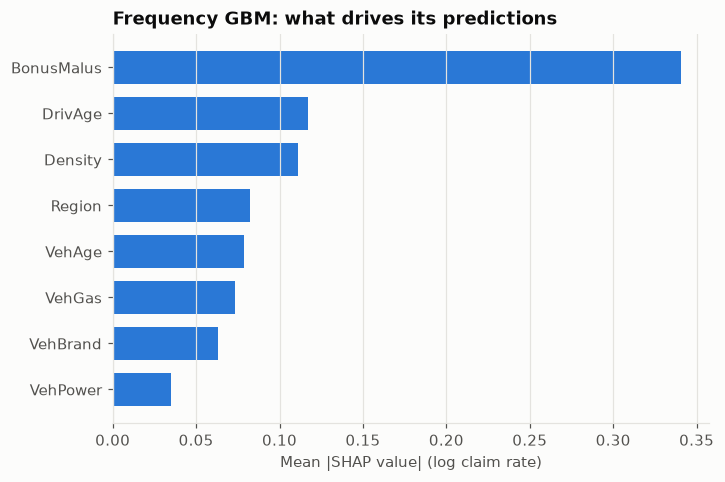

In [8]:
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = np.sort(rng.choice(train.height, 20_000, replace=False))
sample = train[sample_idx]
X_sample = to_numeric(gbm_matrix(sample), freq_gbm)
assert np.allclose(freq_gbm.predict(X_sample.to_numpy(), raw_score=True), freq_gbm.predict(gbm_matrix(sample), raw_score=True))

explainer = shap.TreeExplainer(freq_gbm)
shap_values = explainer.shap_values(X_sample.to_numpy())
names = list(X_sample.columns)
fig = plot_importance(names, np.abs(shap_values).mean(axis=0), "Mean |SHAP value| (log claim rate)", "Frequency GBM: what drives its predictions")
save(fig, "com_shap_importance")
plt.show()

### SHAP against GLM relativities

To compare like with like, the SHAP values for a factor are averaged within each of the GLM's bands and turned into a relativity to the GLM's base band: $\exp(\text{mean SHAP in band} - \text{mean SHAP in base band})$. This is the GBM's view of each band's effect, holding the rest of the policy as it is, next to the GLM's relativity.

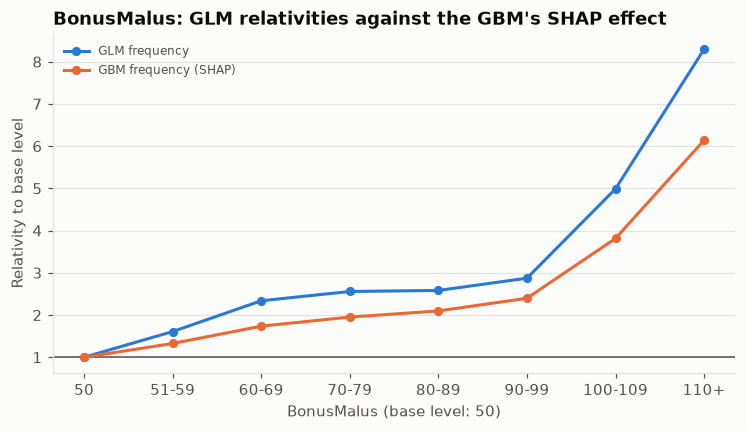

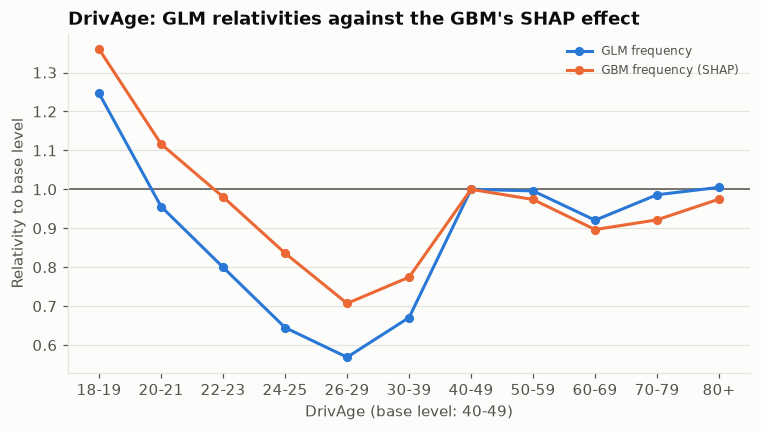

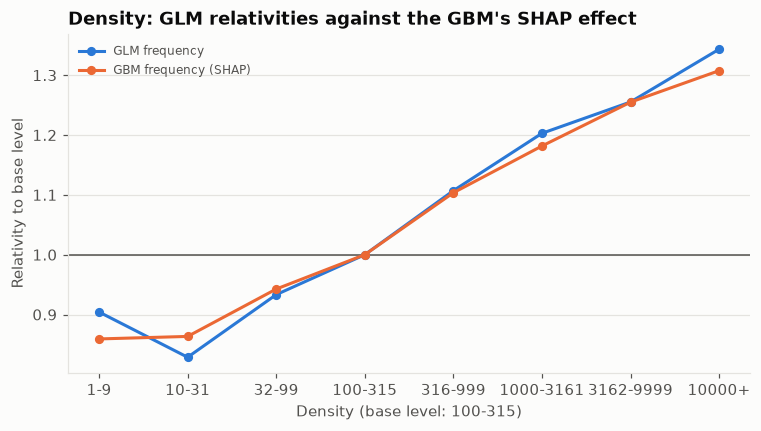

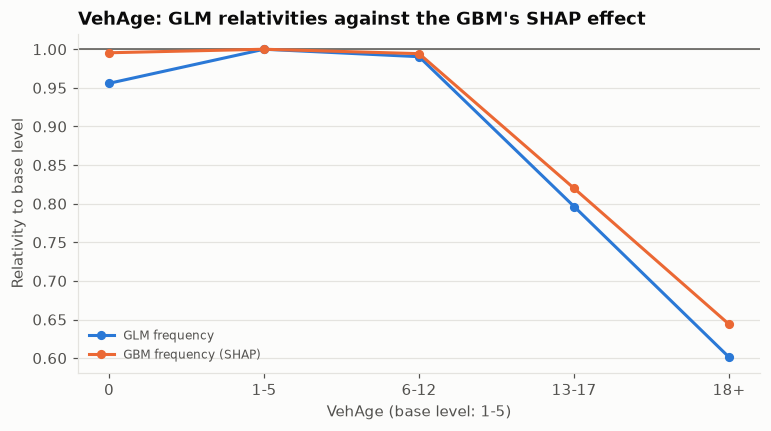

In [9]:
sample_banded = add_glm_bands(sample)
glm_rel = relativities(freq_glm["results"], freq_glm["levels"], freq_glm["base"])
for factor in ["BonusMalus", "DrivAge", "Density", "VehAge"]:
    lvls = band_labels(BANDS[factor])
    col = shap_values[:, names.index(factor)]
    band = sample_banded[factor].to_numpy()
    base_level = freq_glm["base"][factor]
    base_mean = col[band == base_level].mean()
    gbm_rel = [float(np.exp(col[band == lvl].mean() - base_mean)) if (band == lvl).any() else np.nan for lvl in lvls]
    glm_vals = [glm_rel.filter((pl.col("factor") == factor) & (pl.col("level") == lvl))["relativity"][0] for lvl in lvls]
    fig = plot_relativity_comparison({"GLM frequency": glm_vals, "GBM frequency (SHAP)": gbm_rel}, lvls, factor, base_level)
    fig.axes[0].set_title(f"{factor}: GLM relativities against the GBM's SHAP effect")
    save(fig, f"com_shap_vs_glm_{factor.lower()}")
    plt.show()

For most bands the two models agree on direction and rough size, which is reassuring: the GBM has learned the same main effects a pricing team would expect. The GBM's effects are generally flatter, partly because SHAP spreads some of each effect into interactions with other factors, and the GLM puts it all into main effects.

The BonusMalus chart hides the most important difference, because the GBM's effect varies a lot **within** each band. Plotting the SHAP value against the exact BonusMalus shows why:

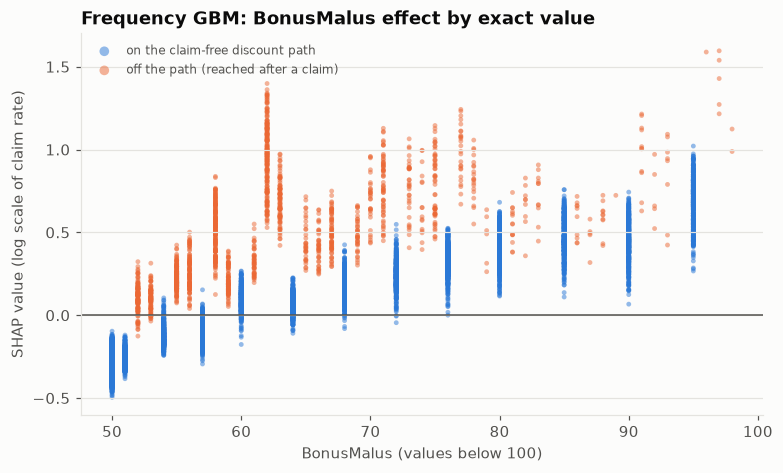

In [10]:
bm = sample["BonusMalus"].to_numpy()
off = sample.select(off_discount_path()).to_series().to_numpy() == 1
mask = bm < 100
fig = plot_shap_dependence(
    bm[mask], shap_values[mask, names.index("BonusMalus")],
    {"on the claim-free discount path": ~off[mask], "off the path (reached after a claim)": off[mask]},
    "BonusMalus (values below 100)", "Frequency GBM: BonusMalus effect by exact value",
)
save(fig, "com_shap_bonusmalus_path")
plt.show()

The French BonusMalus coefficient falls by 5% for each claim-free year, rounded down: from 100 a claim-free driver passes through 95, 90, 85, 80, 76, 72, 68, 64, 60, 57, 54, 51 and 50. A claim multiplies it by 1.25. So a value below 100 that is **off** that path (52, 53, 55, 58, 62, ...) can only be reached after a recent claim.

The GBM has learned this from the data alone: at any BonusMalus level, off-path values carry a much higher claim rate than on-path values. The GLM's bands of ten mix the two groups and charge them the same.

### Interactions

SHAP interaction values split each prediction further, into pairs of factors acting together. They are computed on 5,000 of the sampled training policies, as they are slow to calculate.

In [11]:
interaction_values = explainer.shap_interaction_values(X_sample.iloc[:5000].to_numpy())
strength = np.abs(interaction_values).mean(axis=0)
pairs = [
    {"factor 1": names[i], "factor 2": names[j], "mean |interaction|": float(2 * strength[i, j])}
    for i in range(len(names)) for j in range(i + 1, len(names))
]
pl.DataFrame(pairs).sort("mean |interaction|", descending=True).head(6)

factor 1,factor 2,mean |interaction|
str,str,f64
"""DrivAge""","""BonusMalus""",0.087
"""BonusMalus""","""Region""",0.063
"""BonusMalus""","""VehBrand""",0.039
"""BonusMalus""","""VehAge""",0.028
"""DrivAge""","""Region""",0.028
"""Density""","""Region""",0.025


The strongest interaction is **driver age with BonusMalus**, which also has a clear explanation. Every new driver starts at 100 and needs years without a claim to reach 50. For a young driver, a BonusMalus of 90 mostly means "new"; for a 50-year-old it means "has claimed recently". The same value carries different information at different ages, which a GLM with separate age and BonusMalus factors cannot represent.

## 5. Stretch: feeding the GBM's finding back into the GLM

A GLM can learn what the GBM found if it is given the right feature. Two additions were tested on a validation split inside the training data (80% to fit, 20% to validate):

| Addition to the frequency GLM | Parameters | Validation deviance | Validation Gini |
|---|---|---|---|
| none (current GLM) | 0 | 0.4633 | 0.291 |
| off-discount-path flag | 1 | 0.4591 | 0.313 |
| BonusMalus band x age 30+ | 7 | 0.4630 | 0.294 |
| both | 8 | 0.4591 | 0.314 |

The single off-path flag captures almost all of the gain; the age interaction adds very little once the flag is in, even though its relativities make sense. The flag is kept alone: one extra rating factor, easy to explain, and derived from how the BonusMalus scale works. The frequency GLM is refitted on the full training data with it, combined with the unchanged severity GLM, and scored on the test set.

In [12]:
def glm_plus_matrix(df):
    X = glm_design_matrix(add_glm_bands(df), freq_glm["levels"], freq_glm["base"])
    return pd.concat([X, df.select(off_discount_path()).to_pandas()], axis=1)


glm_plus = fit_poisson_glm(glm_plus_matrix(train), train["ClaimNb"].to_numpy(), train["Exposure"].to_numpy())
off_rel, off_lo, off_hi = np.exp([glm_plus.params["OffDiscountPath"], *glm_plus.conf_int().loc["OffDiscountPath"]])
print(f"Off-discount-path relativity: {off_rel:.2f} (95% interval {off_lo:.2f} to {off_hi:.2f})")
freq_plus_test = predict(glm_plus, glm_plus_matrix(test))
del glm_plus
_ = gc.collect()

Off-discount-path relativity: 2.37 (95% interval 2.26 to 2.48)


In [13]:
claims = test["ClaimNb"].to_numpy()
sev_glm_test = pred_test["glm"] / pred_test["freq_glm"]
freq_models = {"GLM": pred_test["freq_glm"], "GLM + off-path flag": freq_plus_test, "GBM": pred_test["freq_gbm"]}
pp_models = {"GLM": pred_test["glm"], "GLM + off-path flag": freq_plus_test * sev_glm_test, "GBM": pred_test["gbm"]}

rows = []
for m in freq_models:
    rows.append({"model": m, "frequency deviance": poisson_deviance(claims, freq_models[m], expo),
                 "frequency gini": gini(claims, freq_models[m], expo),
                 "pure premium deviance (p1.8)": tweedie_deviance(cost, pp_models[m], expo, 1.8),
                 "pure premium gini": gini(cost, pp_models[m], expo)})
stretch = pl.DataFrame(rows)


def gap_closed(col):
    glm, plus, gbm = stretch[col].to_list()
    return (plus - glm) / (gbm - glm)


print(stretch)
for col in stretch.columns[1:]:
    print(f"Share of the GLM-to-GBM gap closed, {col}: {gap_closed(col):.0%}")

shape: (3, 5)
┌────────────────┬────────────────────┬────────────────┬─────────────────┬───────────────────┐
│ model          ┆ frequency deviance ┆ frequency gini ┆ pure premium    ┆ pure premium gini │
│ ---            ┆ ---                ┆ ---            ┆ deviance (p1.8) ┆ ---               │
│ str            ┆ f64                ┆ f64            ┆ ---             ┆ f64               │
│                ┆                    ┆                ┆ f64             ┆                   │
╞════════════════╪════════════════════╪════════════════╪═════════════════╪═══════════════════╡
│ GLM            ┆ 0.463              ┆ 0.293          ┆ 29.923          ┆ 0.311             │
│ GLM + off-path ┆ 0.458              ┆ 0.311          ┆ 29.777          ┆ 0.332             │
│ flag           ┆                    ┆                ┆                 ┆                   │
│ GBM            ┆ 0.454              ┆ 0.326          ┆ 29.612          ┆ 0.354             │
└────────────────┴──────────────────

In [14]:
plus_prem = pp_models["GLM + off-path flag"] * total / np.sum(pp_models["GLM + off-path flag"] * expo)
moved_plus = float(np.sum(np.abs(gbm_prem - plus_prem) * expo) / 2)
print(f"Premium that would move between customers, GLM -> GBM:          EUR {redistributed:,.0f} ({redistributed / total:.1%})")
print(f"Premium that would move between customers, GLM + flag -> GBM:   EUR {moved_plus:,.0f} ({moved_plus / total:.1%})")

Premium that would move between customers, GLM -> GBM:          EUR 1,249,187 (12.9%)
Premium that would move between customers, GLM + flag -> GBM:   EUR 1,151,207 (11.9%)


One extra parameter, suggested by the GBM and explainable in one sentence, closes **about half** of the gap between the GLM and the GBM on the test set: just over half for frequency, and a little under half for pure premium, on both deviance and Gini. Its relativity, about 2.4, says a policy that has claimed its way off the discount path claims about 2.4 times as often as an otherwise similar one.

The amount of premium the GBM would still move between customers falls only a little, from about 12.9% to 11.9%. The two measures answer different questions. The flag fixes a concentrated group where the GLM was badly wrong, which matters a lot for deviance and Gini. The GBM also makes many small adjustments to most other policies, from interactions and finer effects, and each of those still counts towards the premium it would move. Closing the rest of the gap would take several more features, each adding a little.

This is a common way GBMs are used in pricing: not deployed directly, but as a search tool that finds structure a pricing team can then add to its GLM in a form it can explain, file and govern.

## 6. The trade-off

The numbers above show what the GBM is worth. Whether to use it depends on things the data cannot settle. The main considerations:

| | GLM | GBM |
|---|---|---|
| **Accuracy** (test set) | lower; misprices identifiable segments by 30% or more | better on deviance and Gini, and the double lift confirms its re-rating |
| **Transparency** | a rating table: base rate times one relativity per factor, readable by anyone | needs SHAP or similar to explain; no single table of factors |
| **Explaining an individual price** | direct from the table | possible with SHAP, but each explanation is an approximation built after the fact |
| **Governance and change control** | small number of parameters; easy to review, sign off and monitor | hundreds of trees; harder to review, and more sensitive to changes in the data |
| **Checking for unfair outcomes** | each factor's effect is visible and can be challenged | interactions can recreate the effect of a factor not in the model, so outcomes need testing directly |
| **Implementation** | fits into existing rating engines | may need new infrastructure, or approximation as a table |

UK context, covered in more detail in the README: the FCA's General Insurance Pricing Practices rules (since January 2022) ban charging renewing customers more than equivalent new customers, and firms must be able to show that their pricing does not produce unfair outcomes, including for customers with protected characteristics. Neither model uses price or tenure, so the renewal rule is not affected by the choice of model, but the ability to explain and test outcomes favours whatever is more transparent.

**Questions for the recommendation** (answered in the README):

1. Is the gain from the GBM large enough to justify the extra governance, explanation and monitoring work?
2. Would the GLM with GBM-suggested improvements (section 5) capture enough of the gain to be the better choice?
3. What would an underwriter, a regulator and a pricing manager each want to see before any change?